#  Artificial Intelligence and Machine Learning. Practical Aspects of Training CNN for Image Classification Task.


In [4]:
import os
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError
from tensorflow.keras.layers import BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [34]:
train_dir = "/content/drive/MyDrive/AI/workshop5/FruitinAmazon/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AI/workshop5/FruitinAmazon/FruitinAmazon/test"

# Task 1: Data Understanding and Visualization

In [23]:
# Get class names (subdirectories)
class_names = sorted(os.listdir(train_dir))
if not class_names:
  print("No class directories found in the train folder!")
else:
  print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [24]:
corrupted_images = [] # List to store corrupted images path
# Loop through each class folder and check for corrupted images
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path): # Ensure it’s a valid directory
    images = os.listdir(class_path)
    for img_name in images:
      img_path = os.path.join(class_path, img_name)
      try:
        with Image.open(img_path) as img:
          img.verify() # Verify image integrity
      except (IOError, UnidentifiedImageError):
        corrupted_images.append(img_path)
# Print results
if corrupted_images:
  print("\nCorrupted Images Found:")
  for img in corrupted_images:
    print(img)
else:
  print("\nNo corrupted images found.")


No corrupted images found.


In [26]:
# Dictionary to store class counts
class_counts = {}
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg'
    , '.jpeg'))]
    class_counts[class_name] = len(images) # Count images in each class
# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
  print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                   5
cupuacu                                5
graviola                               5
guarana                                5
pupunha                                5
tucuma                                 5


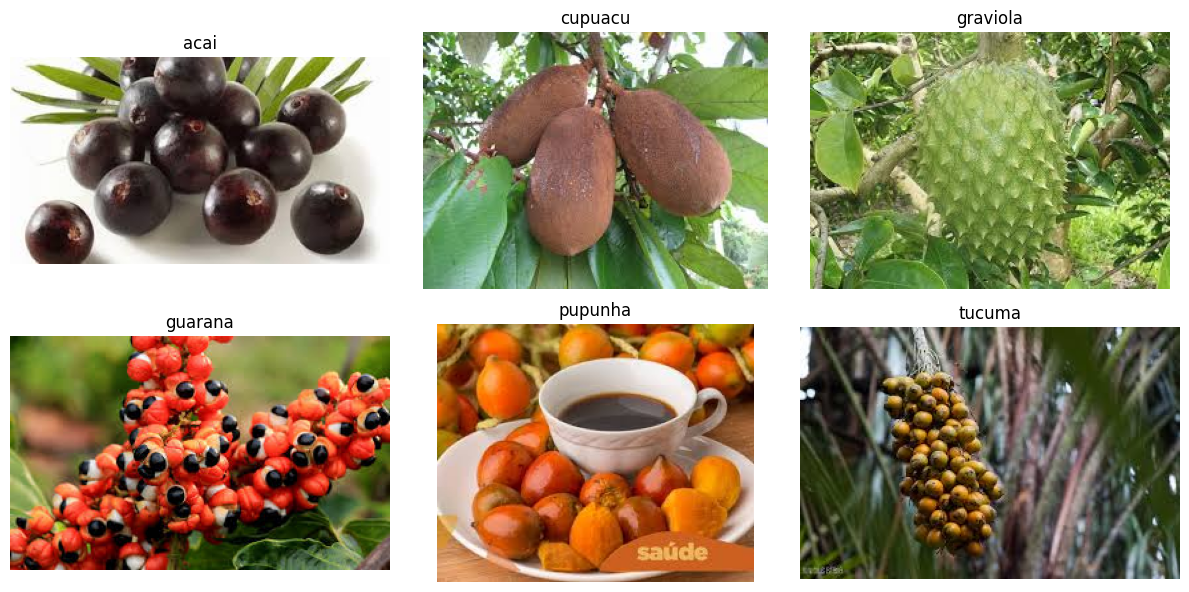

In [10]:
selected_images = [] # Store image paths
selected_labels = [] # Store corresponding class names
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg'
    , '.jpeg'))]
    if images: # Ensure the class folder is not empty
      selected_img = os.path.join(class_path, random.choice(images))
      selected_images.append(selected_img)
      selected_labels.append(class_name)
# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
  if i < num_classes:
    img = mpimg.imread(selected_images[i])
    ax.imshow(img)
    ax.set_title(selected_labels[i])
    ax.axis("off")
  else:
    ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

# Task 2: Loading and Preprocessing Image Data

In [11]:
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='bilinear',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='bilinear',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

num_classes = len(train_ds.class_names)
class_names = train_ds.class_names

Found 30 files belonging to 6 classes.
Using 24 files for training.
Found 30 files belonging to 6 classes.
Using 6 files for validation.


# Task 3: Implementing CNN

In [12]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
], name="data_augmentation")

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

val_ds = val_ds.prefetch(AUTOTUNE)  # No augmentation on val

In [13]:
model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Rescaling(1./255),         # Only normalization here

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# Task 4: Compilin and Training the Model

In [15]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/AI/workshop6/workshop6.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [31]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    # batch_size=16,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8333 - loss: 0.4500
Epoch 1: val_loss improved from None to 1.66926, saving model to /content/drive/MyDrive/AI/workshop6/workshop6.h5



Epoch 1: finished saving model to /content/drive/MyDrive/AI/workshop6/workshop6.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8333 - loss: 0.4500 - val_accuracy: 0.0000e+00 - val_loss: 1.6693
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7500 - loss: 0.5200
Epoch 2: val_loss did not improve from 1.66926
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.7500 - loss: 0.5200 - val_accuracy: 0.0000e+00 - val_loss: 1.6718
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7083 - loss: 0.6338
Epoch 3: val_loss did not improve from 1.66926
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.7083 - loss: 0.6338 - val_accuracy: 0.0000e+00 - val_loss: 1.6753
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8750 - loss: 0.3896
Epoch 4: val_loss did not improve from 1.66926
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8750 - loss: 0.3896 - val_accuracy: 0.0000e+00 - val_loss: 1.6846
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6250 - 


Epoch 10: finished saving model to /content/drive/MyDrive/AI/workshop6/workshop6.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.7500 - loss: 0.5195 - val_accuracy: 0.0000e+00 - val_loss: 1.6595
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8750 - loss: 0.5738
Epoch 11: val_loss did not improve from 1.65947
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8750 - loss: 0.5738 - val_accuracy: 0.0000e+00 - val_loss: 1.6609
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7083 - loss: 0.6844
Epoch 12: val_loss did not improve from 1.65947
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.7083 - loss: 0.6844 - val_accuracy: 0.0000e+00 - val_loss: 1.6642
Epoch 13/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6667 - loss: 0.9455
Epoch 13: val_loss did not improve from 1.65947
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.6667 - loss: 0.9455 - val_accuracy: 0.0000e+00 - val_loss: 1.6654
Epoch 14/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0

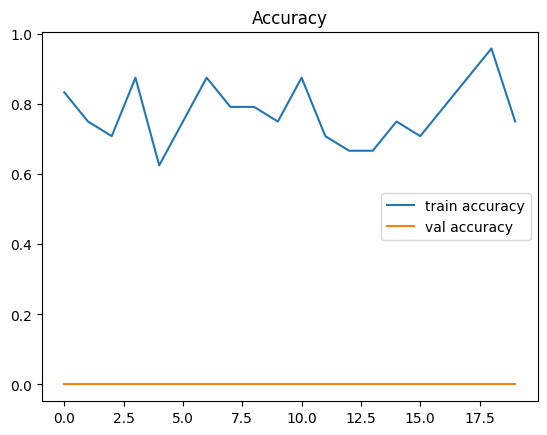

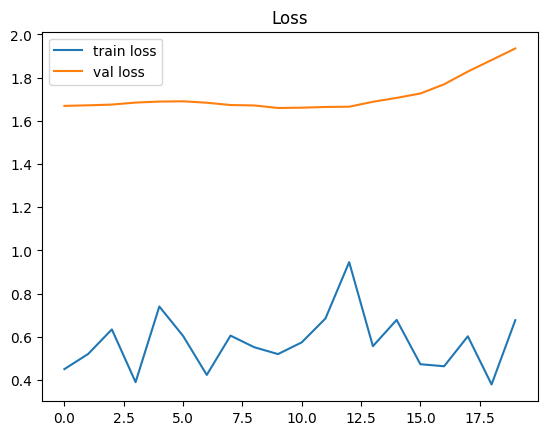

In [32]:
# Accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

# Task 5: Evaluating the Model

In [35]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(128, 128),
    batch_size=32,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (x/255.0, y))

Found 30 files belonging to 6 classes.


In [36]:
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.1667 - loss: 2.0756
Test Loss: 2.0756
Test Accuracy: 0.1667


In [37]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred = np.argmax(model.predict(test_ds), axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 561ms/step
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.17      1.00      0.29         5
    graviola       0.00      0.00      0.00         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.17        30
   macro avg       0.03      0.17      0.05        30
weighted avg       0.03      0.17      0.05        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Transfer Learning

In [38]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
], name="data_augmentation")

AUTOTUNE = tf.data.AUTOTUNE

train_ds_ready = train_ds.map(
    lambda x, y: (data_augmentation(preprocess_input(x), training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

val_ds_ready = val_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

test_ds_ready = test_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

In [39]:
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze all base layers

model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,846 (9.26 MB)

 Trainable params: 167,302 (653.52 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [41]:
checkpoint_p1 = ModelCheckpoint(
    "/content/drive/MyDrive/AI/workshop6/transfer-workshop6.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop_p1 = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("=" * 50)
print("PHASE 1: Training head only (base frozen)")
print("=" * 50)

history = model.fit(
    train_ds_ready,
    validation_data=val_ds_ready,
    epochs=30,
    callbacks=[checkpoint_p1, early_stop_p1]
)

PHASE 1: Training head only (base frozen)
Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3333 - loss: 1.9849
Epoch 1: val_loss improved from None to 1.99933, saving model to /content/drive/MyDrive/AI/workshop6/transfer-workshop6.h5



Epoch 1: finished saving model to /content/drive/MyDrive/AI/workshop6/transfer-workshop6.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.3333 - loss: 1.9849 - val_accuracy: 0.0000e+00 - val_loss: 1.9993
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 813ms/step - accuracy: 0.2500 - loss: 1.8269
Epoch 2: val_loss improved from 1.99933 to 1.98366, saving model to /content/drive/MyDrive/AI/workshop6/transfer-workshop6.h5



Epoch 2: finished saving model to /content/drive/MyDrive/AI/workshop6/transfer-workshop6.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2500 - loss: 1.8269 - val_accuracy: 0.1667 - val_loss: 1.9837
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 804ms/step - accuracy: 0.2083 - loss: 1.6769
Epoch 3: val_loss did not improve from 1.98366
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2083 - loss: 1.6769 - val_accuracy: 0.1667 - val_loss: 1.9847
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 795ms/step - accuracy: 0.0833 - loss: 2.2149
Epoch 4: val_loss improved from 1.98366 to 1.94487, saving model to /content/drive/MyDrive/AI/workshop6/transfer-workshop6.h5



Epoch 4: finished saving model to /content/drive/MyDrive/AI/workshop6/transfer-workshop6.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0833 - loss: 2.2149 - val_accuracy: 0.1667 - val_loss: 1.9449
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3333 - loss: 1.7108
Epoch 5: val_loss improved from 1.94487 to 1.86425, saving model to /content/drive/MyDrive/AI/workshop6/transfer-workshop6.h5



Epoch 5: finished saving model to /content/drive/MyDrive/AI/workshop6/transfer-workshop6.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3333 - loss: 1.7108 - val_accuracy: 0.1667 - val_loss: 1.8643
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1667 - loss: 2.3731
Epoch 6: val_loss improved from 1.86425 to 1.82701, saving model to /content/drive/MyDrive/AI/workshop6/transfer-workshop6.h5



Epoch 6: finished saving model to /content/drive/MyDrive/AI/workshop6/transfer-workshop6.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1667 - loss: 2.3731 - val_accuracy: 0.1667 - val_loss: 1.8270
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 816ms/step - accuracy: 0.3333 - loss: 2.0160
Epoch 7: val_loss did not improve from 1.82701
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3333 - loss: 2.0160 - val_accuracy: 0.1667 - val_loss: 1.8513
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 828ms/step - accuracy: 0.2083 - loss: 2.4408
Epoch 8: val_loss did not improve from 1.82701
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2083 - loss: 2.4408 - val_accuracy: 0.1667 - val_loss: 1.8995
Epoch 9/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 767ms/step - accuracy: 0.2500 - loss: 2.0405
Epoch 9: val_loss did not improve from 1.82701
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2500 - loss: 2.0405 - val_accuracy: 0.1667 - val_loss: 2.0193
Epoch 10/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 809ms/step - accuracy: 0.3


Phase 1 — Test Loss: 2.0703 | Test Accuracy: 0.1667


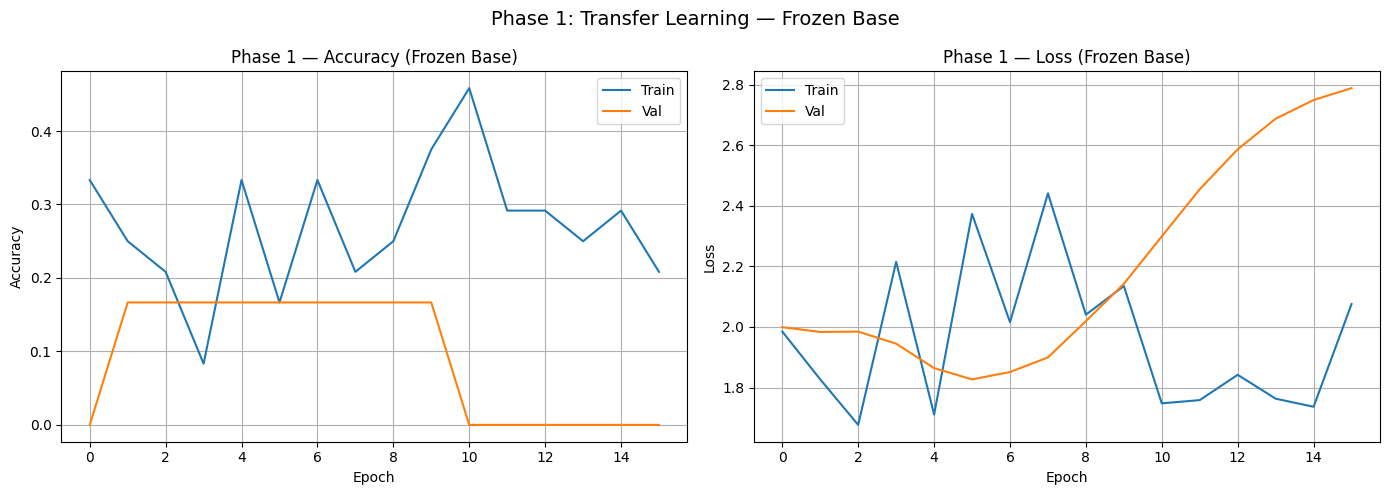

In [42]:
# Evaluate after phase 1
loss_p1, acc_p1 = model.evaluate(test_ds_ready, verbose=0)
print(f"\nPhase 1 — Test Loss: {loss_p1:.4f} | Test Accuracy: {acc_p1:.4f}")

# Plot phase 1 curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Phase 1 — Accuracy (Frozen Base)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Phase 1 — Loss (Frozen Base)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Phase 1: Transfer Learning — Frozen Base', fontsize=14)
plt.tight_layout()
plt.show()

In [43]:
# Unfreeze last 20 layers
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

print(f"Total base layers:   {len(base_model.layers)}")
print(f"Trainable layers:    {sum(1 for l in base_model.layers if l.trainable)}")
print(f"Frozen layers:       {sum(1 for l in base_model.layers if not l.trainable)}")

# Recompile with very low LR
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_p2 = ModelCheckpoint(
    "best_model_finetuned.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop_p2 = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

print("\n" + "=" * 50)
print("PHASE 2: Fine-tuning (last 20 layers unfrozen)")
print("=" * 50)

history_fine = model.fit(
    train_ds_ready,
    validation_data=val_ds_ready,
    epochs=20,
    callbacks=[checkpoint_p2, early_stop_p2]
)

Total base layers:   154
Trainable layers:    20
Frozen layers:       134

PHASE 2: Fine-tuning (last 20 layers unfrozen)
Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.2500 - loss: 2.3192
Epoch 1: val_loss improved from None to 1.82425, saving model to best_model_finetuned.h5



Epoch 1: finished saving model to best_model_finetuned.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 0.2500 - loss: 2.3192 - val_accuracy: 0.1667 - val_loss: 1.8243
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0833 - loss: 3.2065
Epoch 2: val_loss improved from 1.82425 to 1.82170, saving model to best_model_finetuned.h5



Epoch 2: finished saving model to best_model_finetuned.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0833 - loss: 3.2065 - val_accuracy: 0.1667 - val_loss: 1.8217
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2500 - loss: 1.9364
Epoch 3: val_loss improved from 1.82170 to 1.81973, saving model to best_model_finetuned.h5



Epoch 3: finished saving model to best_model_finetuned.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2500 - loss: 1.9364 - val_accuracy: 0.1667 - val_loss: 1.8197
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 964ms/step - accuracy: 0.2917 - loss: 1.6419
Epoch 4: val_loss improved from 1.81973 to 1.81844, saving model to best_model_finetuned.h5



Epoch 4: finished saving model to best_model_finetuned.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2917 - loss: 1.6419 - val_accuracy: 0.1667 - val_loss: 1.8184
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 997ms/step - accuracy: 0.2917 - loss: 2.3806
Epoch 5: val_loss improved from 1.81844 to 1.81524, saving model to best_model_finetuned.h5


...


Epoch 16: finished saving model to best_model_finetuned.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2500 - loss: 2.3019 - val_accuracy: 0.1667 - val_loss: 1.7773
Epoch 17/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2500 - loss: 2.0899
Epoch 17: val_loss improved from 1.77733 to 1.77426, saving model to best_model_finetuned.h5



Epoch 17: finished saving model to best_model_finetuned.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2500 - loss: 2.0899 - val_accuracy: 0.1667 - val_loss: 1.7743
Epoch 18/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 900ms/step - accuracy: 0.2917 - loss: 2.1167
Epoch 18: val_loss improved from 1.77426 to 1.77097, saving model to best_model_finetuned.h5



Epoch 18: finished saving model to best_model_finetuned.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2917 - loss: 2.1167 - val_accuracy: 0.1667 - val_loss: 1.7710
Epoch 19/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 971ms/step - accuracy: 0.1250 - loss: 2.0782
Epoch 19: val_loss improved from 1.77097 to 1.76831, saving model to best_model_finetuned.h5



Epoch 19: finished saving model to best_model_finetuned.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1250 - loss: 2.0782 - val_accuracy: 0.1667 - val_loss: 1.7683
Epoch 20/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 915ms/step - accuracy: 0.0833 - loss: 2.2616
Epoch 20: val_loss improved from 1.76831 to 1.76580, saving model to best_model_finetuned.h5



Epoch 20: finished saving model to best_model_finetuned.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0833 - loss: 2.2616 - val_accuracy: 0.1667 - val_loss: 1.7658



Phase 2 — Test Loss: 2.1049 | Test Accuracy: 0.1667


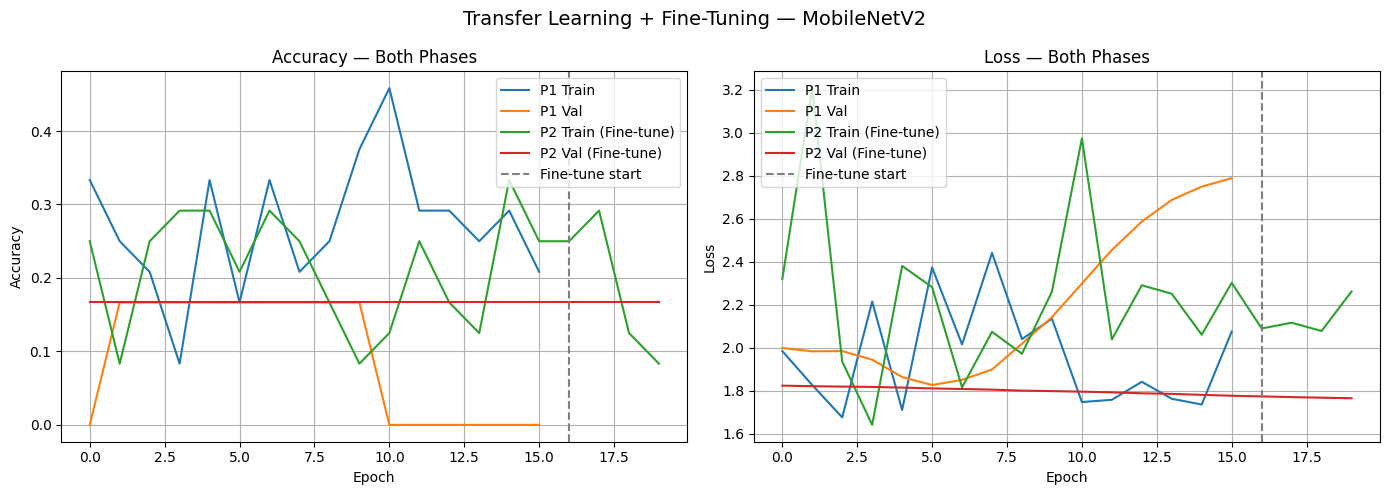

In [44]:
loss_p2, acc_p2 = model.evaluate(test_ds_ready, verbose=0)
print(f"\nPhase 2 — Test Loss: {loss_p2:.4f} | Test Accuracy: {acc_p2:.4f}")

# Combined plot — both phases
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],           label='P1 Train')
axes[0].plot(history.history['val_accuracy'],       label='P1 Val')
axes[0].plot(history_fine.history['accuracy'],      label='P2 Train (Fine-tune)')
axes[0].plot(history_fine.history['val_accuracy'],  label='P2 Val (Fine-tune)')
axes[0].axvline(len(history.history['accuracy']), color='gray', linestyle='--', label='Fine-tune start')
axes[0].set_title('Accuracy — Both Phases')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'],           label='P1 Train')
axes[1].plot(history.history['val_loss'],       label='P1 Val')
axes[1].plot(history_fine.history['loss'],      label='P2 Train (Fine-tune)')
axes[1].plot(history_fine.history['val_loss'],  label='P2 Val (Fine-tune)')
axes[1].axvline(len(history.history['loss']), color='gray', linestyle='--', label='Fine-tune start')
axes[1].set_title('Loss — Both Phases')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Transfer Learning + Fine-Tuning — MobileNetV2', fontsize=14)
plt.tight_layout()
plt.show()

In [45]:
y_true = []
y_pred = []

for images, labels in val_ds_ready:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Print sample predictions
print("=" * 55)
print(f"{'#':<6} {'True Label':<15} {'Predicted':<15} {'Result'}")
print("=" * 55)
for i in range(min(15, len(y_true))):
    true_name = class_names[y_true[i]]
    pred_name = class_names[y_pred[i]]
    result    = "✅" if y_true[i] == y_pred[i] else "❌"
    print(f"{i+1:<6} {true_name:<15} {pred_name:<15} {result}")

#      True Label      Predicted       Result
1      pupunha         pupunha         ✅
2      tucuma          guarana         ❌
3      tucuma          acai            ❌
4      tucuma          cupuacu         ❌
5      tucuma          cupuacu         ❌
6      tucuma          pupunha         ❌


In [47]:
from sklearn.metrics import classification_report
import numpy as np

labels = list(range(len(class_names)))

print(classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=class_names
))

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         0
     cupuacu       0.00      0.00      0.00         0
    graviola       0.00      0.00      0.00         0
     guarana       0.00      0.00      0.00         0
     pupunha       0.50      1.00      0.67         1
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.17         6
   macro avg       0.08      0.17      0.11         6
weighted avg       0.08      0.17      0.11         6



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

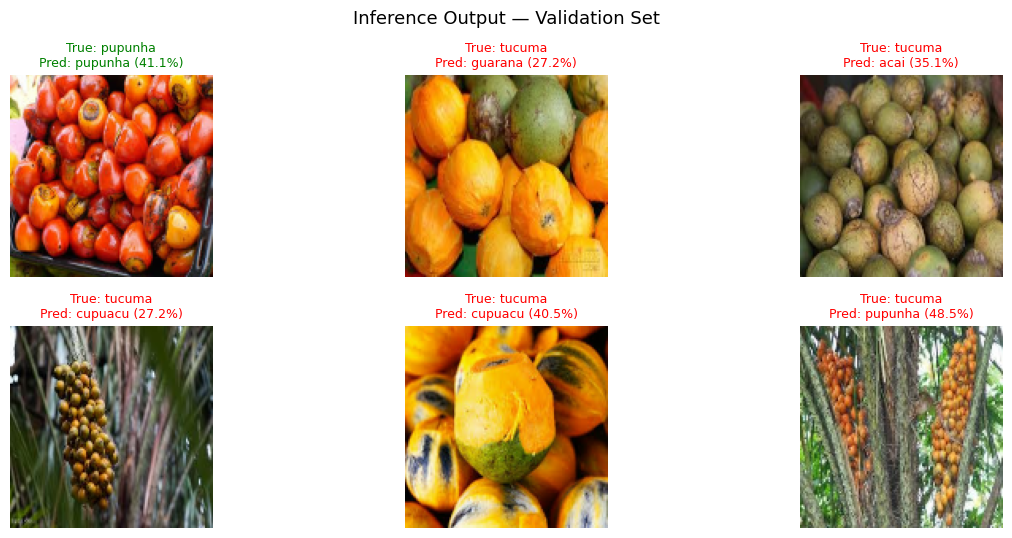

In [48]:
sample_images, sample_labels = next(iter(val_ds_ready))
preds = model.predict(sample_images, verbose=0)

plt.figure(figsize=(12, 8))
for i in range(min(9, len(sample_images))):
    ax = plt.subplot(3, 3, i + 1)
    img_display = (sample_images[i].numpy() + 1) / 2.0  # Denormalize [-1,1] → [0,1]
    plt.imshow(np.clip(img_display, 0, 1))
    true_label  = class_names[sample_labels[i]]
    pred_label  = class_names[np.argmax(preds[i])]
    confidence  = np.max(preds[i]) * 100
    color = "green" if true_label == pred_label else "red"
    plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)", color=color, fontsize=9)
    plt.axis("off")

plt.suptitle("Inference Output — Validation Set", fontsize=13)
plt.tight_layout()
plt.show()

# Task 6: Saving and Loading the Model

In [49]:
model.save("/content/drive/MyDrive/AI/workshop6/transfer_model.h5")

In [50]:
from tensorflow.keras.models import load_model

loaded_model = load_model("/content/drive/MyDrive/AI/workshop6//transfer_model.h5")

In [51]:
loss, acc = loaded_model.evaluate(test_ds_ready)

print(f"Loaded Model Accuracy: {acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.1667 - loss: 2.1049
Loaded Model Accuracy: 0.1667
